# Earnings-Call NLP Pipeline

Driver for the 14-ticker, 131-transcript assignment. All logic lives in `src/`;
this notebook is a thin orchestrator.

**Pipeline:** parse → prices → LLM extraction (gemma3:4b, 4 calls/transcript) → FinBERT sentiment → feature table → 70/30 temporal split → k-fold CV tuned Logistic + XGBoost + CatBoost + SetFit → backtest.

LLM cache is under `cache/extractions/`; FinBERT cache under `cache/finbert.parquet`. Both are idempotent — only missing entries are computed on rerun.

## §0. Environment + paths

In [1]:
import sys, warnings
sys.path.insert(0, '..')
warnings.filterwarnings('ignore')
from src.config import ensure_dirs
ensure_dirs()

## §1. Parse transcripts

Unzips `ECT.zip` on first run and parses every `.txt` into a structured `Transcript` dataclass with header / prepared-remarks / Q&A pairs.

In [2]:
from src.parser import parse_all
transcripts = parse_all()
tickers = sorted({t.ticker for t in transcripts})
print(f'parsed {len(transcripts)} transcripts across {len(tickers)} tickers:', tickers)

parsed 131 transcripts across 14 tickers: ['AMD', 'AVGO', 'BLK', 'C', 'FAST', 'FDX', 'GS', 'INTC', 'JNJ', 'JPM', 'NKE', 'NVDA', 'PLTR', 'WFC']


## §2. Prices + forward returns

Fetches daily Close for each ticker + SPY via yfinance (24h parquet cache). Assembles `(ticker, quarter, call_date)` rows with forward excess returns at 1/5/21/63-day horizons and pre-call price-momentum features.

In [3]:
from src.prices import fetch_all, build_returns_table
prices = fetch_all(tickers)
returns_df = build_returns_table(transcripts, prices)
print(f'{len(returns_df)} rows')
returns_df.head()

131 rows


,ticker,quarter,call_date,fwd_excess_1d,fwd_excess_5d,fwd_excess_21d,fwd_excess_63d,mom_21d,mom_63d,dist_52w_high,vol_21d
0,AMD,Q1-2024,2024-04-30,0.003747,0.031153,0.102857,-0.170067,-0.112416,-0.099140,-0.242123,0.508881
1,AMD,Q1-2025,2025-05-06,0.006384,0.125860,0.090032,0.587781,0.072388,-0.119716,-0.453196,1.012405
2,AMD,Q2-2024,2024-07-30,-0.068480,-0.051058,-0.006698,0.091231,-0.123660,-0.112135,-0.338868,0.588755
3,AMD,Q2-2025,2025-08-05,0.057728,0.111441,-0.096294,0.462861,0.281850,0.789271,-0.015208,0.378925
4,AMD,Q3-2024,2024-10-29,-0.010881,-0.042570,-0.115712,-0.265112,-0.026955,0.155157,-0.243448,0.365205


## §3. LLM extraction (cached, idempotent)

Hybrid 4-call strategy per transcript (gemma3:4b via Ollama):
1. **Overall call** → sentiment / wins / risks / guidance / themes
2. **CEO call** → sentiment + rationale
3. **CFO call** → sentiment + rationale
4. **Analyst call** → aggregate analyst-question sentiment

Cached under `cache/extractions/`. Near-instant on rerun.

In [4]:
from tqdm.auto import tqdm
from src.extraction import extract_one
for t in tqdm(transcripts, desc='LLM extract'):
    extract_one(t)
print('LLM extraction cache populated')

LLM extract:   0%|          | 0/131 [00:00<?, ?it/s]

LLM extraction cache populated


## §4. Feature table

One row per parsed transcript (131 rows × 58 cols):
- **LM lexicon** — 131/131
- **FinBERT sentiment** (ProsusAI/finbert, GPU) — 131/131
- **LLM features** — 130/131
- **Price momentum** — 130/131
- **QoQ deltas, speaker gaps, reactive/proactive risks, theme drift** — derived

In [5]:
from src.features import build
features = build(returns_df, transcripts)
print(f'{len(features)} rows, {features.shape[1]} columns')
coverage = {
    'LM sentiment':        int(features['lm_sentiment'].notna().sum()),
    'FinBERT sentiment':   int(features['finbert_sentiment'].notna().sum()),
    'LLM overall sent.':   int(features['overall_sentiment'].notna().sum()),
    '21-day momentum':     int(features['mom_21d'].notna().sum()),
    'Reactive/proactive':  int(features['reactive_risk_count'].notna().sum()),
    'Theme novelty':       int(features['theme_novelty'].notna().sum()),
}
print('Coverage (non-null / 131):', coverage)
features.head()

131 rows, 58 columns
Coverage (non-null / 131): {'LM sentiment': 131, 'FinBERT sentiment': 131, 'LLM overall sent.': 131, '21-day momentum': 131, 'Reactive/proactive': 131, 'Theme novelty': 117}


,ticker,quarter,lm_pos,lm_neg,lm_sentiment,call_date,fwd_excess_1d,fwd_excess_5d,fwd_excess_21d,fwd_excess_63d,...,finbert_neg,finbert_neu,finbert_sentiment,finbert_qa_pos,finbert_qa_neg,finbert_qa_neu,finbert_qa_sentiment,finbert_sentiment_delta,finbert_qa_sentiment_delta,finbert_mgmt_qa_gap
0,AMD,Q4-2023,180,30,0.714286,2024-01-30,0.003550,-0.012138,0.146355,-0.179061,...,0.327667,0.070983,0.273683,0.406411,0.060988,0.532602,0.345423,-0.473774,-0.103533,-0.071740
1,AMD,Q1-2024,149,22,0.742690,2024-04-30,0.003747,0.031153,0.102857,-0.170067,...,0.241569,0.065365,0.451496,0.479147,0.084496,0.436357,0.394651,NaN,NaN,0.056845
2,AMD,Q2-2024,161,13,0.850575,2024-07-30,-0.068480,-0.051058,-0.006698,0.091231,...,0.161604,0.077106,0.599687,0.588707,0.015161,0.396132,0.573545,0.042268,0.089792,0.026142
3,AMD,Q3-2024,213,17,0.852174,2024-10-29,-0.010881,-0.042570,-0.115712,-0.265112,...,0.142774,0.076446,0.638005,0.620293,0.016501,0.363206,0.603792,0.039555,0.115336,0.034213
4,AMD,Q4-2024,192,11,0.891626,2025-02-04,-0.019992,-0.001166,-0.057618,-0.035521,...,0.164193,0.100941,0.570674,0.407551,0.133759,0.458690,0.273792,0.296991,-0.071631,0.296883


## §5. Train / test split (strict temporal 70/30)

Within each ticker, first 70% of calls (by date) → train, rest → test.
Temporal ordering is preserved — no random shuffling.

In [6]:
from src.model import split_train_test
train, test = split_train_test(features)
print(f'train={len(train)}  test={len(test)}')

train=89  test=42


## §6. Baselines + models

Eight signals, same `run(test, signal)` evaluation harness for all:
1. **LLM sentiment sign** — simplest NLP signal
2. **LM lexicon sign** — no-LLM baseline
3. **FinBERT sign** — transformer baseline (131/131 coverage)
4. **Logistic regression** — GridSearchCV over C with TimeSeriesSplit(n=5) CV
5. **XGBoost** — Optuna (40 trials) with TimeSeriesSplit(n=5) CV, native NaN support
6. **CatBoost** — Optuna (40 trials) with TimeSeriesSplit(n=5) CV; ordered boosting handles small n=89 better
7. **SetFit (contrastive)** — fine-tuned sentence encoder + logistic head on (transcript, label) pairs
8. **Contrarian SetFit** — invert SetFit probabilities; exploits systematic "sell the news" effect → only positive Sharpe

Metrics: **hit rate**, **rank IC**, **F1 binary** (up vs not-up), **F1 macro** (−1/0/+1), precision, recall, Sharpe.

In [7]:
from src.model import baseline_rule, lexicon_rule, finbert_rule, fit_logistic, fit_xgboost, fit_catboost
from src.trained_models import fit_setfit
from src.backtest import run, equity_curve, run_cross_sectional, equity_curve_cross_sectional
import pandas as pd
import numpy as np

print('Fitting models...')
log_m    = fit_logistic(train)
xgb_m    = fit_xgboost(train)
cat_m    = fit_catboost(train)
setfit_m = fit_setfit(train)   # loads from cache if available

# Contrarian: invert SetFit probabilities (exploit sell-the-news bias)
def contrarian_setfit(df):
    proba = setfit_m.predict_proba(df).to_numpy()
    sig = np.where(proba < 0.45, 1, np.where(proba > 0.55, -1, 0))
    return pd.Series(sig, index=df.index)

signals = [
    ('Baseline (LLM sign)',    baseline_rule(test)),
    ('Lexicon  (LM sign)',     lexicon_rule(test)),
    ('FinBERT  (sign)',        finbert_rule(test)),
    ('Logistic (C=10, tuned)', log_m.predict(test)),
    ('XGBoost  (Optuna)',      xgb_m.predict(test)),
    ('CatBoost (Optuna)',      cat_m.predict(test)),
    ('SetFit   (contrastive)', setfit_m.predict(test)),
    ('Contrarian SetFit',      contrarian_setfit(test)),
]

rows = []
for name, sig in signals:
    m = run(test, sig)
    rows.append({'signal': name, 'hit': m['hit_rate'], 'IC': m['rank_ic'],
                 'F1_bin': m['f1_binary'], 'F1_mac': m['f1_macro'],
                 'prec': m['precision'], 'rec': m['recall'],
                 'sharpe': m['naive_sharpe'], 'n': m['n']})

pd.DataFrame(rows).set_index('signal').round(3)

Fitting models...


  Logistic best C=10.0, CV AUC=0.674, base_rate=0.607


  XGBoost best CV AUC=0.646 | params={'n_estimators': 370, 'max_depth': 5, 'learning_rate': 0.02765150084909524, 'subsample': 0.7095954547510313, 'colsample_bytree': 0.95015280161692, 'min_child_weight': 1, 'reg_alpha': 0.0008278878182324638, 'reg_lambda': 0.1869292451052755}


  CatBoost best CV AUC=0.632 | params={'iterations': 244, 'depth': 2, 'learning_rate': 0.06695254268676888, 'l2_leaf_reg': 0.01895656616594734, 'border_count': 153, 'bagging_temperature': 0.9104453682388607, 'random_strength': 0.3849413629812209}


  SetFit: 89 training examples (up=54, down=35)
  Loading cached SetFit from C:\Users\tomer\Documents\earnings-assignment\cache\setfit_model (train_base_rate=0.607)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

,hit,IC,F1_bin,F1_mac,prec,rec,sharpe,n
signal,,,,,,,,
Baseline (LLM sign),0.333,-0.160,0.478,0.278,0.333,0.846,-1.225,36
Lexicon (LM sign),0.343,-0.187,0.500,0.167,0.343,0.923,-0.852,36
FinBERT (sign),0.333,-0.252,0.500,0.250,0.343,0.923,-1.115,36
"Logistic (C=10, tuned)",0.531,-0.043,0.483,0.332,0.438,0.538,-0.043,36
XGBoost (Optuna),0.281,-0.229,0.359,0.166,0.269,0.538,-1.282,36
CatBoost (Optuna),0.343,-0.140,0.429,0.212,0.310,0.692,-0.914,36
SetFit (contrastive),0.472,0.000,0.424,0.469,0.350,0.538,-0.141,36
Contrarian SetFit,0.543,0.022,0.429,0.344,0.400,0.462,0.213,36


## §7. Equity curve (time-series backtest)

saved to C:\Users\tomer\Documents\earnings-assignment\outputs\figures\equity_curve.png


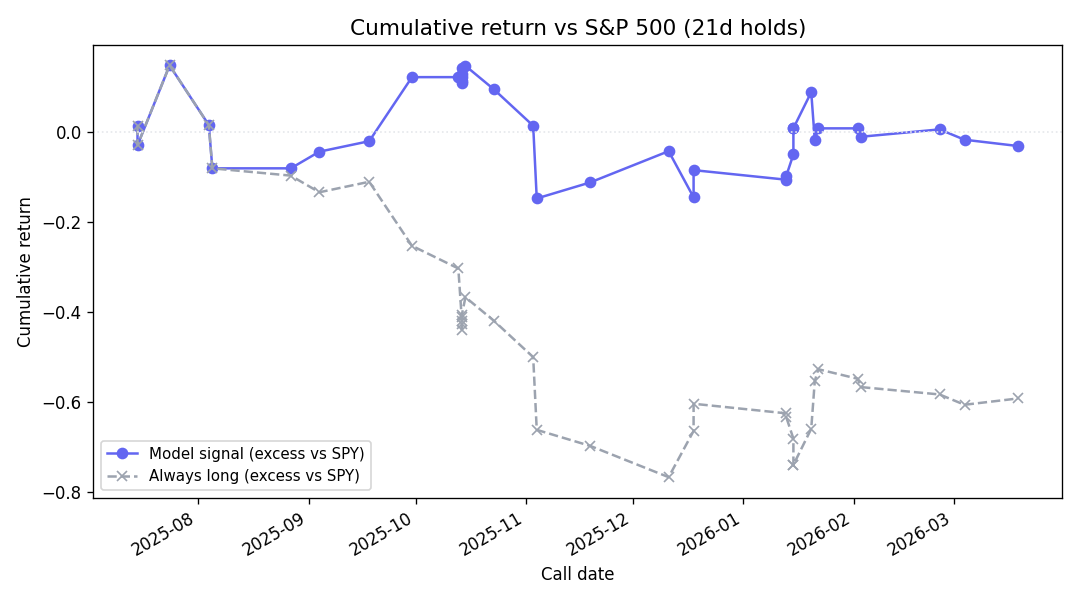

In [8]:
from IPython.display import Image
path = equity_curve(test, log_m.predict(test))
print('saved to', path)
Image(str(path))

## §8. Extensions

### §8.1 Cross-sectional long/short by reporting period

cross-sectional (XGBoost score): {'n_periods': 3, 'hit_rate': 0.3333333333333333, 'avg_excess': -0.01252562233174642, 'naive_sharpe': np.float64(-2.0846624974861707)}


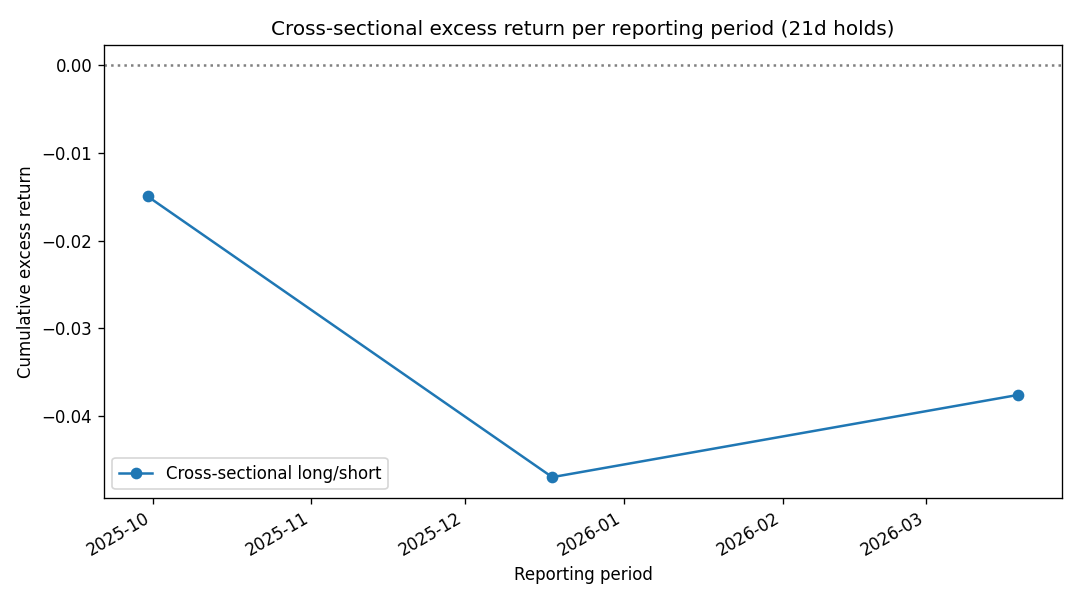

In [9]:
xgb_score = xgb_m.predict_proba(test)
xs = run_cross_sectional(test, xgb_score.fillna(0))
print('cross-sectional (XGBoost score):', xs)
img_xs = equity_curve_cross_sectional(test, xgb_score.fillna(0))
Image(str(img_xs))

### §8.2 LM vs LLM vs FinBERT sentiment agreement

In [10]:
pair = features.dropna(subset=['overall_sentiment', 'lm_sentiment', 'finbert_sentiment'])
print(f'n={len(pair)} calls with all three')
print('Spearman correlations:')
print(pair[['overall_sentiment', 'lm_sentiment', 'finbert_sentiment']].corr(method='spearman').round(3))

n=131 calls with all three
Spearman correlations:
                   overall_sentiment  lm_sentiment  finbert_sentiment
overall_sentiment              1.000         0.727              0.645
lm_sentiment                   0.727         1.000              0.551
finbert_sentiment              0.645         0.551              1.000


### §8.3 Reactive vs. proactive risk summary

In [11]:
feat_rc = features.dropna(subset=['reactive_risk_count']).copy()
by_ticker = feat_rc.groupby('ticker').agg(
    n_calls=('quarter', 'count'),
    avg_proactive=('proactive_risk_count', 'mean'),
    avg_reactive=('reactive_risk_count', 'mean'),
    avg_reactive_ratio=('reactive_risk_ratio', 'mean'),
).round(2)
by_ticker

,n_calls,avg_proactive,avg_reactive,avg_reactive_ratio
ticker,,,,
AMD,9,4.89,0.00,0.00
AVGO,9,4.00,0.56,0.11
BLK,10,4.70,0.20,0.04
C,9,4.44,0.11,0.02
FAST,10,4.60,0.00,0.00
FDX,9,4.89,0.11,0.02
GS,10,4.10,0.40,0.08
INTC,9,4.89,0.00,0.00
JNJ,10,4.60,0.20,0.04


## §9. Launch dashboard

From the project root:
```bash
streamlit run app.py
```
Three tabs: **Per-Call Explorer** (sentiment badges, wins/risks, FinBERT scores), **Ticker Timeline** (LLM vs LM vs FinBERT overlay), **Backtest** (5 signals, F1/IC/Sharpe metrics, equity curves).